# Notebook 15 – Overfitting & Underfitting


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data.csv", encoding="latin1")
df = df.dropna(subset=["Description"]).copy()
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
df["IsCancelled"] = df["InvoiceNo"].astype(str).str.startswith("C").astype(int)
df["AbsQuantity"] = df["Quantity"].abs()
df["Month"] = df["InvoiceDate"].dt.month
df["IsInternational"] = (df["Country"] != "United Kingdom").astype(int)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,IsCancelled,AbsQuantity,Month,IsInternational
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,0,6,12,0
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,0,8,12,0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,0,6,12,0


## Setting Up a Clean, Visual Example

Underfitting and overfitting are easiest to *see* on a simple curve, so
this notebook starts with a small synthetic dataset before returning to
the real retail data. A noisy sample is generated from a known,
non-linear curve (`y = sin(x)` plus random noise) — because the true
relationship is known here, both a model that's too simple and a model
that's too complex can be clearly diagnosed against it.

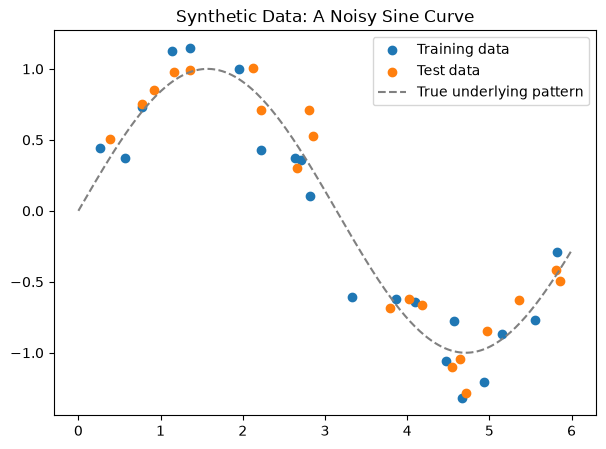

In [9]:
rng = np.random.default_rng(42)
x_all = np.sort(rng.uniform(0, 6, size=40))
y_all = np.sin(x_all) + rng.normal(scale=0.25, size=len(x_all))

x_train, x_test, y_train, y_test = x_all[::2], x_all[1::2], y_all[::2], y_all[1::2]  # simple 50/50 split
x_smooth = np.linspace(0, 6, 300)  # for drawing smooth curves

plt.figure(figsize=(7, 5))
plt.scatter(x_train, y_train, label="Training data", color="tab:blue")
plt.scatter(x_test, y_test, label="Test data", color="tab:orange")
plt.plot(x_smooth, np.sin(x_smooth), linestyle="--", color="gray", label="True underlying pattern")
plt.legend()
plt.title("Synthetic Data: A Noisy Sine Curve")
plt.show()

## Demonstrating Underfitting, a Good Fit, and Overfitting

The same kind of model — polynomial regression — is fit three times to
the exact same training data, varying only its **complexity** (the
polynomial's degree): degree 1 (a straight line), degree 4 (a moderate
curve), and degree 15 (an extremely flexible curve). Each is then judged
by how well it matches the *true* underlying pattern and the *held-out
test data*, not just the training points it was fit on.

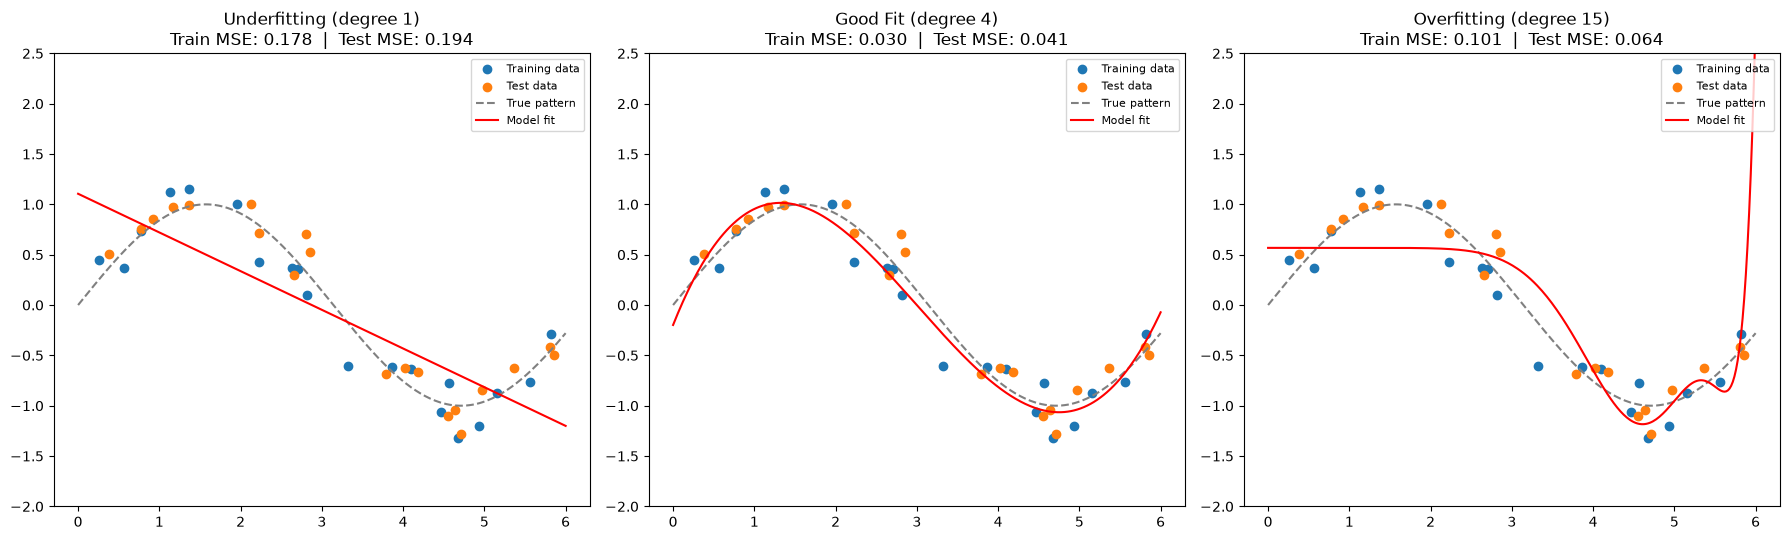

In [10]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

def fit_polynomial(degree, x_train, y_train):
    model = make_pipeline(PolynomialFeatures(degree), LinearRegression())
    model.fit(x_train.reshape(-1, 1), y_train)
    return model

degrees = [1, 4, 15]
titles = ["Underfitting (degree 1)", "Good Fit (degree 4)", "Overfitting (degree 15)"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

for degree, title, ax in zip(degrees, titles, axes):
    model = fit_polynomial(degree, x_train, y_train)
    y_smooth_pred = model.predict(x_smooth.reshape(-1, 1))

    train_mse = mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1)))
    test_mse = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))

    ax.scatter(x_train, y_train, color="tab:blue", label="Training data")
    ax.scatter(x_test, y_test, color="tab:orange", label="Test data")
    ax.plot(x_smooth, np.sin(x_smooth), linestyle="--", color="gray", label="True pattern")
    ax.plot(x_smooth, y_smooth_pred, color="red", label="Model fit")
    ax.set_ylim(-2, 2.5)
    ax.set_title(f"{title}\nTrain MSE: {train_mse:.3f}  |  Test MSE: {test_mse:.3f}")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()

## Underfitting

**What it is:** when a model is too *simple* to capture the real pattern
in the data, so it performs poorly even on the data it was trained on.
Above, the degree-1 (straight-line) model can't bend to follow the sine
wave at all — it has both a high **training** error and a high **test**
error, because it never learned the actual shape of the relationship in
the first place. There's nothing "unfair" happening here: the model is
failing on data it has already seen, which is a clear sign its own
structure is too limited for the task.

## Good Fit

**What it is:** when a model's complexity roughly matches the true
complexity of the underlying pattern. Above, the degree-4 model curves
enough to follow the sine wave's actual shape, without curving so much
that it starts chasing individual noisy points. Both its training and
test error are low and reasonably close to each other — the sign of a
model that's learned the real signal rather than the noise.

## Overfitting

**What it is:** when a model is too *complex* relative to the amount and
noise of the training data, so it starts fitting the specific noise in
the training set rather than the true underlying pattern. Above, the
degree-15 model contorts itself into a wild, wiggly curve that passes
extremely close to nearly every individual training point (very low
training error) — but that wiggliness has nothing to do with the real
sine pattern, so it performs badly on the test data. The giveaway is
exactly this: a large *gap* between training error (very low) and test
error (much higher).

## Bias

**What it is:** error that comes from a model's own assumptions being too
simple or too rigid to represent the true relationship, no matter how
much data it's given. High bias is the underlying *cause* of
underfitting: a straight line simply cannot represent a curve, so it will
systematically miss the pattern in the same predictable way, regardless
of which particular training points happened to be sampled.

## Variance

**What it is:** error that comes from a model being overly sensitive to
the *specific* training data it happened to see — small changes in which
points were sampled lead to wildly different fitted models. High variance
is the underlying *cause* of overfitting: the degree-15 model above would
produce a noticeably different wiggly curve if it were re-fit on a
different random sample of the same underlying process, because it's
reacting to that sample's specific noise rather than the shared, stable
pattern underneath.

Below, this instability is shown directly: the same degree-15 model is
re-fit on several different random subsets of the training data, to see
how much the resulting curves disagree with each other, compared to the
same experiment with the well-fit degree-4 model.

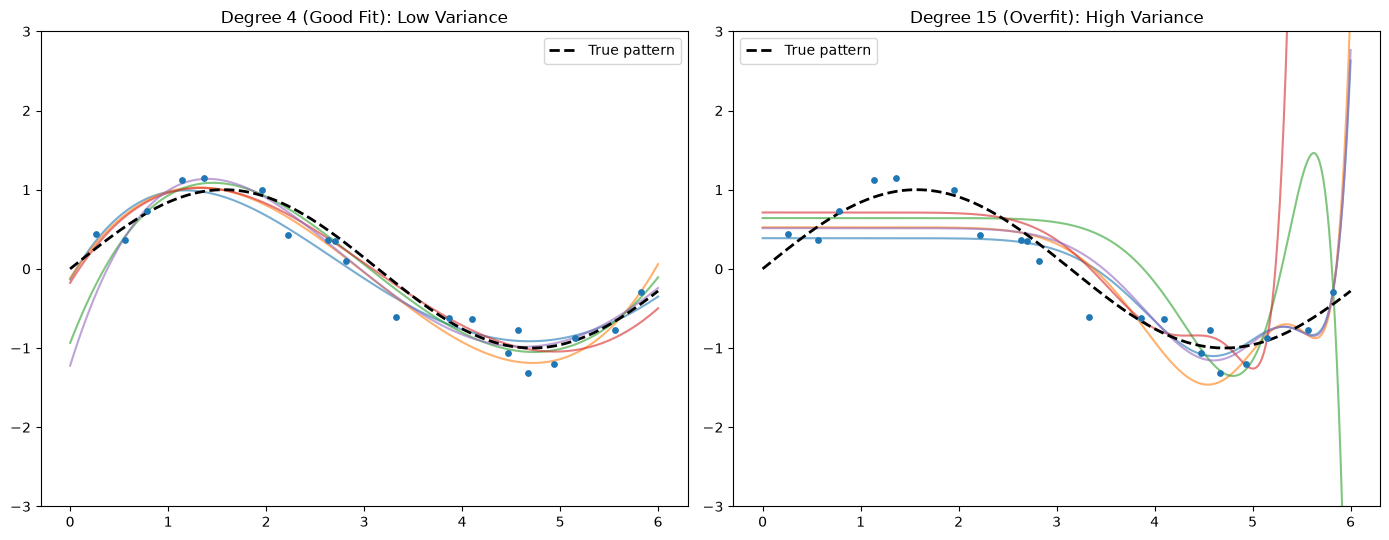

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for degree, ax, title in zip([4, 15], axes, ["Degree 4 (Good Fit): Low Variance", "Degree 15 (Overfit): High Variance"]):
    for trial in range(5):
        trial_rng = np.random.default_rng(trial)
        sample_idx = trial_rng.choice(len(x_train), size=len(x_train), replace=True)  # bootstrap resample
        model = fit_polynomial(degree, x_train[sample_idx], y_train[sample_idx])
        ax.plot(x_smooth, model.predict(x_smooth.reshape(-1, 1)), alpha=0.6)
    ax.plot(x_smooth, np.sin(x_smooth), linestyle="--", color="black", linewidth=2, label="True pattern")
    ax.scatter(x_train, y_train, color="tab:blue", s=15, zorder=5)
    ax.set_ylim(-3, 3)
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

The degree-15 curves swing wildly from one resample to the next,
disagreeing with each other everywhere — that instability *is* variance.
The degree-4 curves, by contrast, stay close together and close to the
true pattern, regardless of which specific resample they were fit on.

## Bias-Variance Tradeoff

**What it is:** the observation that bias and variance move in opposite
directions as model complexity changes — a simple model has high bias
but low variance (it's consistently wrong in the same way); a complex
model has low bias but high variance (it can represent the true pattern,
but is unstable and easily thrown off by noise). Total error can be
thought of as roughly `Bias² + Variance + irreducible noise`, and it's
usually minimized somewhere in the *middle*, not at either extreme. The
"Good Fit" model above sits closer to that middle ground; the whole
practical challenge of model selection is finding it.

Below, training error and test error are tracked across a full range of
polynomial degrees, to see this tradeoff traced out as a curve rather
than just three isolated snapshots.

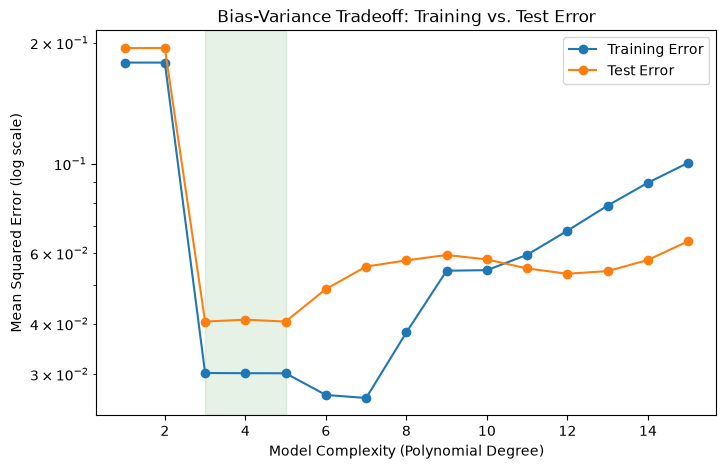

Degree with the lowest test error in this experiment: 3


In [12]:
degree_range = range(1, 16)
train_errors, test_errors = [], []

for degree in degree_range:
    model = fit_polynomial(degree, x_train, y_train)
    train_errors.append(mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1))))
    test_errors.append(mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1))))

plt.figure(figsize=(8, 5))
plt.plot(degree_range, train_errors, marker="o", label="Training Error")
plt.plot(degree_range, test_errors, marker="o", label="Test Error")
plt.yscale("log")
plt.xlabel("Model Complexity (Polynomial Degree)")
plt.ylabel("Mean Squared Error (log scale)")
plt.title("Bias-Variance Tradeoff: Training vs. Test Error")
plt.legend()
plt.axvspan(3, 5, color="green", alpha=0.1, label="Good fit region")
plt.show()

best_degree = degree_range[int(np.argmin(test_errors))]
print("Degree with the lowest test error in this experiment:", best_degree)

Training error keeps dropping as complexity increases (a more flexible
model can always fit its own training data better) — but test error
drops, bottoms out, and then rises again. That upward turn on the right
side of the plot *is* the overfitting zone; the downward-sloping left
side is the underfitting zone. The best complexity sits at the bottom of
the test-error curve, not the bottom of the training-error curve.

## Training Error, Validation Error, and Test Error

These are three different error measurements, each computed on a
*different slice of data*, and mixing them up is a common source of
confusion:

* **Training Error** — the model's error on the exact data it was fit
  on. Always keeps improving (or staying flat) as complexity increases;
  never a trustworthy signal of real-world performance on its own.
* **Validation Error** — the model's error on a separate slice of data
  that isn't used for fitting, but *is* used to make decisions during
  development (choosing hyperparameters like polynomial degree,
  `max_depth`, or `C`). This is the honest score used to tune the model.
* **Test Error** — the model's error on a final, completely held-out
  slice of data that isn't touched at all until the very end, after every
  decision has already been made using the validation set. This is the
  honest score used to report how the finished model will likely perform
  in the real world.

The reason validation and test data must be *separate* sets (not the
same one) is subtle but important: if hyperparameters are tuned by
repeatedly checking performance against the same "test" set, that
set has effectively leaked into the model-selection process, and its
score is no longer an unbiased estimate of real-world performance —
it's just quietly become a second training set.

**Demonstration, on the real retail data:** a Decision Tree's `max_depth`
is swept using proper 5-fold cross-validation (which uses many
temporary validation folds drawn from the training data), reporting
training, validation, and final test error separately.

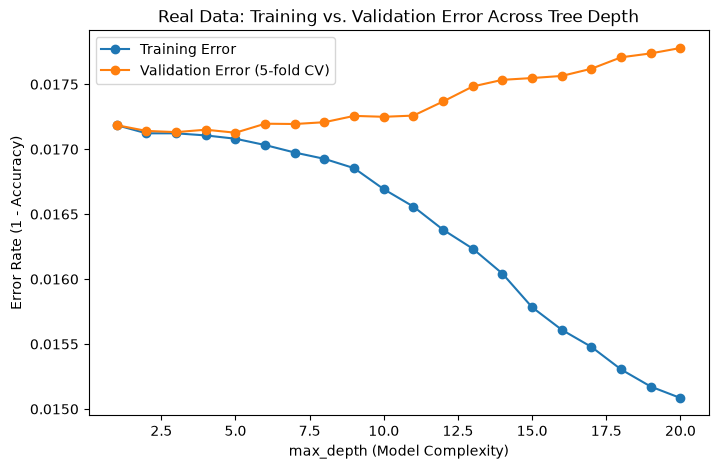

Best max_depth chosen using VALIDATION error only: 5
Final TEST error at that chosen depth (checked only once, at the end): 0.0173


In [13]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score

feature_cols = ["AbsQuantity", "UnitPrice", "Month", "IsInternational"]
X = df[feature_cols]
y = df["IsCancelled"]

# Held-out test set, untouched until the very end
X_trainval, X_test_real, y_trainval, y_test_real = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

depths = range(1, 21)
train_err_real, val_err_real = [], []

for depth in depths:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    # 5-fold cross-validation gives an honest VALIDATION score, without touching the real test set
    val_scores = cross_val_score(model, X_trainval, y_trainval, cv=5, scoring="accuracy")
    val_err_real.append(1 - val_scores.mean())

    model.fit(X_trainval, y_trainval)
    train_err_real.append(1 - model.score(X_trainval, y_trainval))

plt.figure(figsize=(8, 5))
plt.plot(depths, train_err_real, marker="o", label="Training Error")
plt.plot(depths, val_err_real, marker="o", label="Validation Error (5-fold CV)")
plt.xlabel("max_depth (Model Complexity)")
plt.ylabel("Error Rate (1 - Accuracy)")
plt.title("Real Data: Training vs. Validation Error Across Tree Depth")
plt.legend()
plt.show()

best_depth = list(depths)[int(np.argmin(val_err_real))]
print("Best max_depth chosen using VALIDATION error only:", best_depth)

# Only NOW, after the decision is made, is the untouched test set finally used
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X_trainval, y_trainval)
final_test_error = 1 - final_model.score(X_test_real, y_test_real)
print(f"Final TEST error at that chosen depth (checked only once, at the end): {final_test_error:.4f}")

## Model Complexity

**What it is:** a general term for how flexible a model is allowed to
be — polynomial degree, a Decision Tree's `max_depth`, the number of
trees in a Random Forest, an SVM's `C`/`gamma`, the number of features
used, and so on are all, in different ways, knobs that control
complexity. Every experiment in this notebook has really been the same
underlying story told with different knobs: turning complexity up always
helps training error, but only helps test/validation error up to a
point, after which it starts hurting it. Controlling model complexity
deliberately — rather than just making the most powerful model
possible — is the practical core of avoiding both underfitting and
overfitting.

## Regularization – Introduction

**What it is:** a family of techniques that fight overfitting directly,
by adding a penalty for complexity into the model's own training process,
rather than only controlling complexity indirectly (like limiting
`max_depth`, or picking a lower polynomial degree ahead of time).
Regularization typically works by discouraging a model's internal
parameters (e.g. polynomial or regression coefficients) from growing too
large, since very large coefficients are usually a symptom of a model
straining to fit individual noisy points.

Two of the most common forms, both extending ordinary Linear Regression:

* **Ridge Regression (L2 regularization):** adds a penalty proportional
  to the *sum of squared* coefficients, shrinking every coefficient
  toward zero, but rarely all the way to exactly zero.
* **Lasso Regression (L1 regularization):** adds a penalty proportional
  to the *sum of absolute* coefficients, which can shrink some
  coefficients all the way to exactly zero — effectively removing those
  features from the model entirely.

**Demonstration:** the overfit degree-15 polynomial from earlier is
refit with Ridge regularization added, to see the wild wiggling get
tamed without changing the polynomial degree itself at all.

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 3.744824956445063e-26.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_ridge.py:227: LinAlgWarning: An ill-conditioned matrix detected: slice 0 has rcond = 8.177321753528541e-24.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


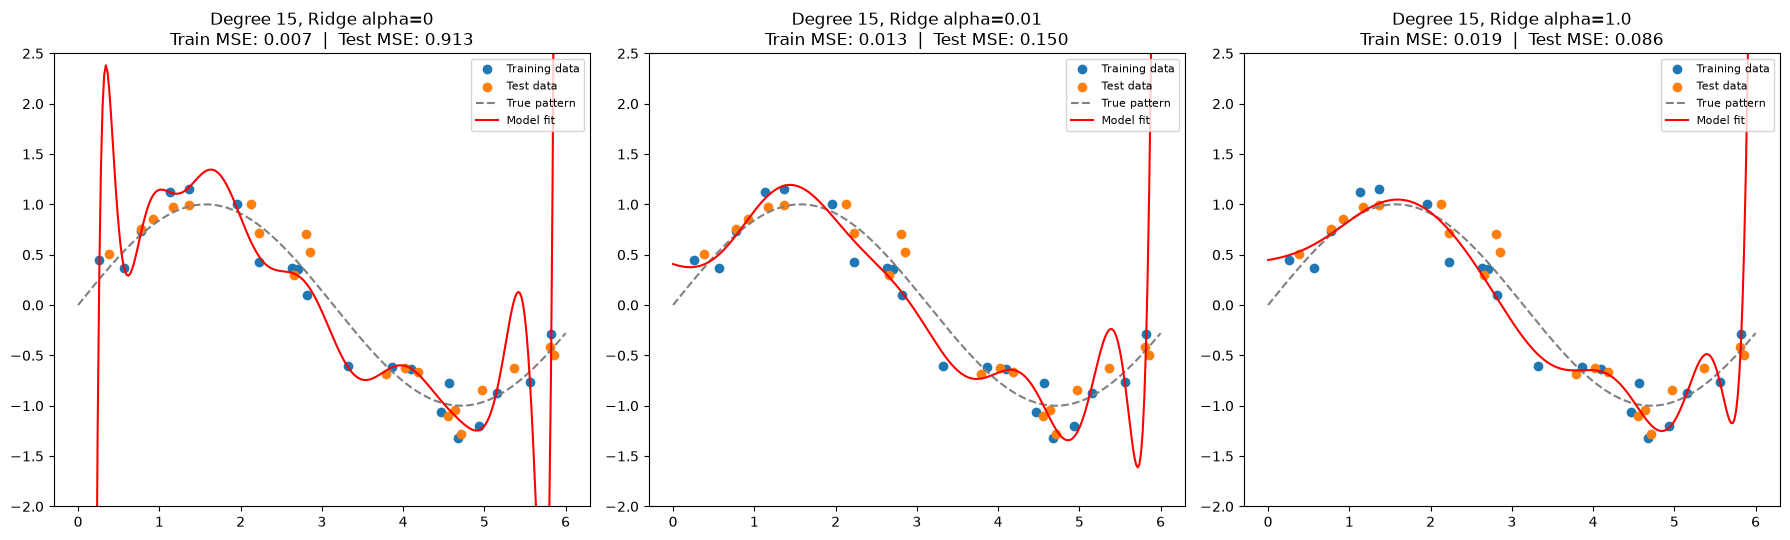

In [14]:
from sklearn.linear_model import Ridge

def fit_ridge_polynomial(degree, alpha, x_train, y_train):
    model = make_pipeline(PolynomialFeatures(degree), Ridge(alpha=alpha))
    model.fit(x_train.reshape(-1, 1), y_train)
    return model

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
alphas = [0, 0.01, 1.0]  # alpha=0 is equivalent to no regularization at all

for alpha, ax in zip(alphas, axes):
    model = fit_ridge_polynomial(15, alpha, x_train, y_train)
    y_smooth_pred = model.predict(x_smooth.reshape(-1, 1))
    train_mse = mean_squared_error(y_train, model.predict(x_train.reshape(-1, 1)))
    test_mse = mean_squared_error(y_test, model.predict(x_test.reshape(-1, 1)))

    ax.scatter(x_train, y_train, color="tab:blue", label="Training data")
    ax.scatter(x_test, y_test, color="tab:orange", label="Test data")
    ax.plot(x_smooth, np.sin(x_smooth), linestyle="--", color="gray", label="True pattern")
    ax.plot(x_smooth, y_smooth_pred, color="red", label="Model fit")
    ax.set_ylim(-2, 2.5)
    ax.set_title(f"Degree 15, Ridge alpha={alpha}\nTrain MSE: {train_mse:.3f}  |  Test MSE: {test_mse:.3f}")
    ax.legend(fontsize=8, loc="upper right")

plt.tight_layout()
plt.show()